In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from scipy.spatial import ConvexHull, QhullError
import seaborn as sns
from xgboost import XGBRegressor

In [2]:
# Extracting temporal features
def toTime(df):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df['month'] = df['time'].dt.month
    df['day'] = df['time'].dt.day
    df['hour'] = df['time'].dt.hour
    df['minute'] = df['time'].dt.minute
    df['second'] = df['time'].dt.second
    df['dayofweek'] = df['time'].dt.dayofweek  # Monday=0, Sunday=6
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    return df

# Create a DataFrame for submission
def submit(test_ids, ylong, ylat):
    # Create a submission DataFrame
    submission = pd.DataFrame({
        'ID': test_ids,  # Pass the test ID column
        'longitude_predicted': ylong,  # Your predicted longitudes
        'latitude_predicted': ylat    # Your predicted latitudes
    })

    # Ensure the correct column order
    submission = submission[['ID', 'longitude_predicted', 'latitude_predicted']].sort_values(by = 'ID').reset_index(drop=True)

    # Find the next available filename by checking existing files
    i = 1
    while os.path.exists(f'jakobs_results_{i}.csv'):
        i += 1

    # Save to CSV with the next available filename
    filename = f'jakobs_results_{i}.csv'
    submission.to_csv(filename, index=False)
    print(f"Results saved to {filename}")

# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Define a function to wrap latitude to the range [-90, 90]
def wrap_latitude(lat):
    if lat > 90:
        return 180 - lat  # Bounce back from the North Pole
    elif lat < -90:
        return -180 - lat  # Bounce back from the South Pole
    return lat

# Define a function to wrap longitude to the range [-180, 180]
def wrap_longitude(lon):
    return ((lon + 180) % 360) - 180  # Wraps around using modulo

def calculate_covered_area(df, lat_col='latitude', long_col='longitude'):
    results = []
    
    # Group by vesselId to calculate the covered area for each vessel
    for vessel_id, vessel_data in df.groupby('vesselId'):
        # Drop any rows with NaN values in the latitude or longitude columns
        vessel_data = vessel_data.dropna(subset=[lat_col, long_col])
        
        # Ensure there are enough unique points to form a hull (at least 3)
        unique_points = vessel_data[[lat_col, long_col]].drop_duplicates()
        if len(unique_points) < 3:
            results.append({'vesselId': vessel_id, 'covered_area': 0})
            continue

        # Convert lat/long to 2D points (in meters) for ConvexHull calculation
        lat_to_m = 111320  # meters per degree latitude
        long_to_m = 40075000 * np.cos(np.radians(vessel_data[lat_col].mean())) / 360  # meters per degree longitude
        
        # Convert latitude and longitude to Cartesian coordinates (in meters)
        points = np.column_stack((unique_points[long_col] * long_to_m, unique_points[lat_col] * lat_to_m))
        
        # Attempt to calculate the convex hull; handle flat cases
        try:
            hull = ConvexHull(points)
            area = hull.volume  # volume returns the area for a 2D hull in scipy
        except QhullError:
            area = 1  # If ConvexHull fails due to flat simplex, set area to 0

        results.append({'vesselId': vessel_id, 'covered_area': area})
    
    # Convert results to DataFrame and return
    return pd.DataFrame(results)

def haversine_distance(lat1, lon1, lat2, lon2):
    # Earth radius in meters
    R = 6371000  

    # Convert latitude and longitude from degrees to radians
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)

    # Haversine formula
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c

    return distance

def average_distance_in_meters(y_true_lat, y_true_long, y_pred_lat, y_pred_long):
    distances = haversine_distance(y_true_lat, y_true_long, y_pred_lat, y_pred_long)
    avg_distance = np.mean(distances)
    return avg_distance

In [3]:
# First we read the necessary csv files. NOTE: Different delimiter for some files.
df_train = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ais_train.csv', delimiter = '|')
df_test = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ais_test.csv')
df_vessels = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/vessels.csv', delimiter = '|')
df_schedules = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/schedules_to_may_2024.csv', delimiter = '|')
df_ports = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ports.csv', delimiter = '|')
# NOTE: Train is sorted by vessel ID and time for model to notice temporal trend.
df_train = df_train.sort_values(by = ['vesselId', 'time'])
df_test = df_test.sort_values(by = ['vesselId', 'time'])

In [4]:
# Merging GT and length into train and test sets
df_train = df_train.merge(df_vessels[['vesselId', 'length', 'GT']], on = 'vesselId', how = 'left')
df_test = df_test.merge(df_vessels[['vesselId', 'length', 'GT']], on = 'vesselId', how = 'left')

In [5]:
# Extracting temporal features
df_train = toTime(df_train)
df_test = toTime(df_test)

In [6]:
# Calculate means of the columns without outliers
sog_mean = df_train.loc[df_train['sog'] < 30, 'sog'].mean()
cog_mean = df_train.loc[df_train['cog'] < 360, 'cog'].mean()
heading_mean = df_train.loc[df_train['heading'] < 360, 'heading'].mean()

# Cleaning the data. Ensuring all data is within reasonable limits and replacing outliers/erranous data with NaN
df_train['cog'] = df_train['cog'].apply(lambda x: float(x) if float(x) < 360 else cog_mean)
# NOTE: We determine that SOG above 25 knots shall be disregarded.
df_train['sog'] = df_train['sog'].apply(lambda x: float(x) if float(x) < 30 else sog_mean)
df_train['heading'] = df_train['heading'].apply(lambda x: float(x) if float(x) < 360 else heading_mean)
# NOTE: Navstat of 0 and 8 both indicate a moving vessel. We therefore combine these two
df_train['navstat'] = df_train['navstat'].replace(8, 0)

In [7]:
# Replacing NaN values in train set with backward fill
df_train['portId'] = df_train['portId'].transform(lambda x: x.bfill())
# Renaming port data and then merging with df_train
df_ports = df_ports.rename(columns = {'latitude': 'port_latitude', 'longitude': 'port_longitude'})
df_train = df_train.merge(df_ports[['portId', 'port_latitude', 'port_longitude']], on = 'portId', how = 'left')

In [8]:
# NOTE: ptv = port to vessel
df_train['portvessel_lat'] = df_train['port_latitude'] - df_train['latitude']
df_train['portvessel_long'] = df_train['port_longitude'] - df_train['longitude']

In [9]:
print(df_train.columns)

Index(['time', 'cog', 'sog', 'rot', 'heading', 'navstat', 'etaRaw', 'latitude',
       'longitude', 'vesselId', 'portId', 'length', 'GT', 'month', 'day',
       'hour', 'minute', 'second', 'dayofweek', 'is_weekend', 'port_latitude',
       'port_longitude', 'portvessel_lat', 'portvessel_long'],
      dtype='object')


In [10]:
lags = 2

In [11]:
def add_lag_features_train(df, num_lags):
    df = df.copy()  # Avoid modifying the original DataFrame

    # Loop over the range of lags to create lagged features
    for lag in range(1, num_lags + 1):
        # Create lagged features for latitude, longitude, sog, cog, and port coordinates
        df[f'lat_lag{lag}'] = df.groupby('vesselId')['latitude'].shift(lag)
        df[f'long_lag{lag}'] = df.groupby('vesselId')['longitude'].shift(lag)
        df[f'sog_lag{lag}'] = df.groupby('vesselId')['sog'].shift(lag)
        df[f'cog_lag{lag}'] = df.groupby('vesselId')['cog'].shift(lag)
        df[f'port_lat_lag{lag}'] = df.groupby('vesselId')['port_latitude'].shift(lag)
        df[f'port_long_lag{lag}'] = df.groupby('vesselId')['port_longitude'].shift(lag)
    
    return df

# Apply to training data
df_train = add_lag_features_train(df_train, lags)

def add_lag_features_to_test(train_df, test_df, num_lags):
    # Step 1: Ensure lag features are calculated in the training set
    for lag in range(1, num_lags + 1):
        train_df[f'lat_lag{lag}'] = train_df.groupby('vesselId')['latitude'].shift(lag)
        train_df[f'long_lag{lag}'] = train_df.groupby('vesselId')['longitude'].shift(lag)
        train_df[f'sog_lag{lag}'] = train_df.groupby('vesselId')['sog'].shift(lag)
        train_df[f'cog_lag{lag}'] = train_df.groupby('vesselId')['cog'].shift(lag)
        train_df[f'port_lat_lag{lag}'] = train_df.groupby('vesselId')['port_latitude'].shift(lag)
        train_df[f'port_long_lag{lag}'] = train_df.groupby('vesselId')['port_longitude'].shift(lag)

    # Step 2: Extract the last known lag values for each vessel in the training set
    last_lag_values = train_df.groupby('vesselId').last().reset_index()

    # Select relevant columns for merging
    lag_columns = ['vesselId'] + [f'lat_lag{lag}' for lag in range(1, num_lags + 1)] + \
                  [f'long_lag{lag}' for lag in range(1, num_lags + 1)] + \
                  [f'sog_lag{lag}' for lag in range(1, num_lags + 1)] + \
                  [f'cog_lag{lag}' for lag in range(1, num_lags + 1)] + \
                  [f'port_lat_lag{lag}' for lag in range(1, num_lags + 1)] + \
                  [f'port_long_lag{lag}' for lag in range(1, num_lags + 1)]
    last_lag_values = last_lag_values[lag_columns]

    # Step 3: Merge the last known lag values with the test set on 'vesselId'
    test_df = test_df.merge(last_lag_values, on='vesselId', how='left')

    return test_df

# Apply to test data
df_test = add_lag_features_to_test(df_train, df_test, lags)

In [14]:
# Calculate the time difference in seconds between each timestamp within each vessel's data
df_train['time_diff'] = df_train.groupby('vesselId')['time'].diff().dt.total_seconds().fillna(0)

# Convert `sog` from knots to meters per second
df_train['sog_mps'] = df_train['sog'] * 0.514444

# Decompose `sog` into latitude and longitude components based on `cog`
# Speed in the north-south (latitude) direction
df_train['speed_lat'] = df_train['sog_mps'] * np.cos(np.radians(df_train['cog']))

# Speed in the east-west (longitude) direction, adjusted by latitude to account for Earth's curvature
df_train['speed_long'] = df_train['sog_mps'] * np.sin(np.radians(df_train['cog'])) / np.cos(np.radians(df_train['latitude']))

# Calculate the expected movement in each direction by multiplying by the time difference
df_train['delta_lat'] = df_train['speed_lat'] * df_train['time_diff'] / 111139  # Convert meters to degrees latitude
df_train['delta_long'] = df_train['speed_long'] * df_train['time_diff'] / 111139  # Convert meters to degrees longitude

# Calculate the expected latitude and longitude by adding the movement to the last known position
df_train['expected_lat'] = df_train['latitude'] + df_train['delta_lat']
df_train['expected_long'] = df_train['longitude'] + df_train['delta_long']

# Wrapping latitude and longitude to ensure they stay within valid bounds
df_train['expected_lat'] = df_train['expected_lat'].apply(wrap_latitude)
df_train['expected_long'] = df_train['expected_long'].apply(wrap_longitude)

# Apply the same transformation to the test set

# Extract the last known vessel position and necessary info from training set for merging with test set
last_known_info = df_train.groupby('vesselId').last()[['latitude', 'longitude', 'sog_mps', 'cog', 'time']]

# Merging this with the test set
df_test = df_test.merge(last_known_info, on='vesselId', how='left', suffixes=('', '_last'))

# Calculate the time difference between the last known time and each test sample in seconds
df_test['time_diff'] = df_test.groupby('vesselId')['time'].diff().dt.total_seconds().fillna(0)

# Decompose `sog_mps` in test set into lat and long components using `cog`
df_test['speed_lat'] = df_test['sog_mps'] * np.cos(np.radians(df_test['cog']))
df_test['speed_long'] = df_test['sog_mps'] * np.sin(np.radians(df_test['cog'])) / np.cos(np.radians(df_test['latitude']))

# Calculate the movement in latitude and longitude directions
df_test['delta_lat'] = df_test['speed_lat'] * df_test['time_diff'] / 111139
df_test['delta_long'] = df_test['speed_long'] * df_test['time_diff'] / 111139

# Calculate the expected latitude and longitude by adding the movement to the last known position
df_test['expected_lat'] = df_test['latitude'] + df_test['delta_lat']
df_test['expected_long'] = df_test['longitude'] + df_test['delta_long']

# Wrapping to ensure latitude and longitude stay within valid bounds
df_test['expected_lat'] = df_test['expected_lat'].apply(wrap_latitude)
df_test['expected_long'] = df_test['expected_long'].apply(wrap_longitude)

# Display the resulting expected positions
print(df_test[['vesselId', 'expected_lat', 'expected_long', 'speed_lat', 'speed_long', 'delta_lat', 'delta_long']])

                        vesselId  expected_lat  expected_long  speed_lat  \
0       61e9f38eb937134a3c4bfd8d     48.533200      -6.120030   0.055308   
1       61e9f38eb937134a3c4bfd8d     48.534006      -6.123202   0.055308   
2       61e9f38eb937134a3c4bfd8d     48.534813      -6.126375   0.055308   
3       61e9f38eb937134a3c4bfd8d     48.533736      -6.122140   0.055308   
4       61e9f38eb937134a3c4bfd8d     48.533560      -6.121445   0.055308   
...                          ...           ...            ...        ...   
51734  clh6aqawa0007gh0z9h6zi9bo     59.950645      21.706311   5.403470   
51735  clh6aqawa0007gh0z9h6zi9bo     59.951569      21.708809   5.403470   
51736  clh6aqawa0007gh0z9h6zi9bo     59.950742      21.706574   5.403470   
51737  clh6aqawa0007gh0z9h6zi9bo     59.952979      21.712621   5.403470   
51738  clh6aqawa0007gh0z9h6zi9bo     59.949138      21.702236   5.403470   

       speed_long  delta_lat  delta_long  
0       -0.217586   0.000000   -0.000000  
1

In [ ]:
df_train.columns

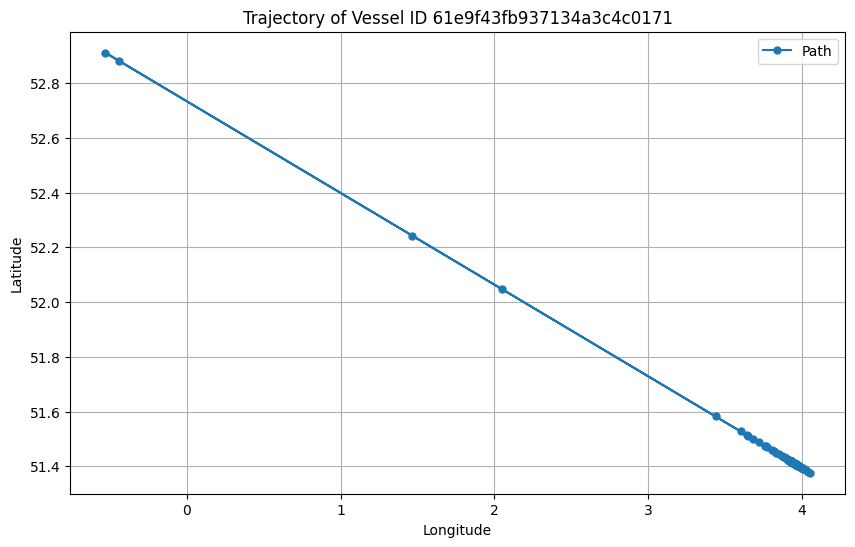

In [15]:
# Define the vessel ID you want to plot
vessel_id = '61e9f43fb937134a3c4c0171'  # Replace with the specific vessel ID you want to plot

# Filter data for the specific vessel ID
vessel_data = df_test[df_test['vesselId'] == vessel_id]
# Plot the latitude and longitude
plt.figure(figsize=(10, 6))
plt.plot(vessel_data['expected_long'], vessel_data['expected_lat'], marker='o', linestyle='-', markersize=5, label='Path')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Trajectory of Vessel ID {vessel_id}')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
label_encoder = LabelEncoder()
df_train['vesselId_encoded'] = label_encoder.fit_transform(df_train['vesselId'])
df_test['vesselId_encoded'] = label_encoder.transform(df_test['vesselId'])

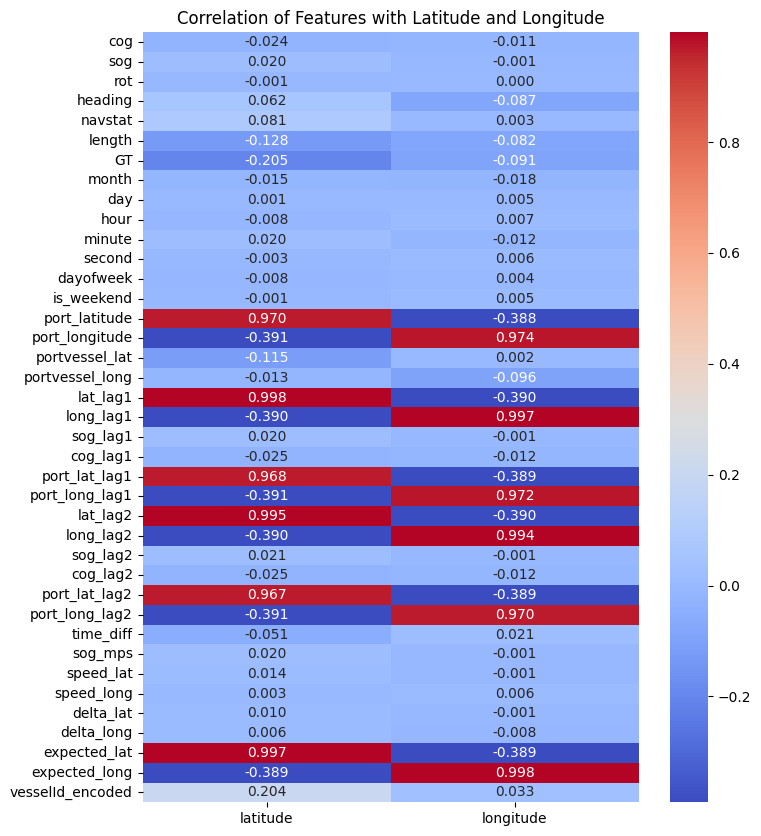

In [19]:
# Define the features you want to analyze
correlationfeatures = ['cog', 'sog', 'rot', 'heading', 'navstat', 'latitude',
       'longitude', 'length', 'GT', 'month', 'day',
       'hour', 'minute', 'second', 'dayofweek', 'is_weekend', 'port_latitude',
       'port_longitude', 'portvessel_lat', 'portvessel_long', 'lat_lag1',
       'long_lag1', 'sog_lag1', 'cog_lag1', 'port_lat_lag1', 'port_long_lag1',
       'lat_lag2', 'long_lag2', 'sog_lag2', 'cog_lag2', 'port_lat_lag2',
       'port_long_lag2', 'time_diff', 'sog_mps', 'speed_lat', 'speed_long',
       'delta_lat', 'delta_long', 'expected_lat', 'expected_long',
       'vesselId_encoded']

# Calculate the correlation matrix
corrMatrix = df_train[correlationfeatures].corr()

# Filter to keep only correlations with 'latitude' and 'longitude'
target_features = ['latitude', 'longitude']
filtered_corrMatrix = corrMatrix[target_features].drop(target_features)  # Drop latitude and longitude rows

# Plot the heatmap with filtered correlation matrix
plt.figure(figsize=(8, 10))
sns.heatmap(filtered_corrMatrix, annot=True, cmap="coolwarm", fmt=".3f", cbar=True)
plt.title("Correlation of Features with Latitude and Longitude")
plt.show()

**Random Forest Regressor for validation**

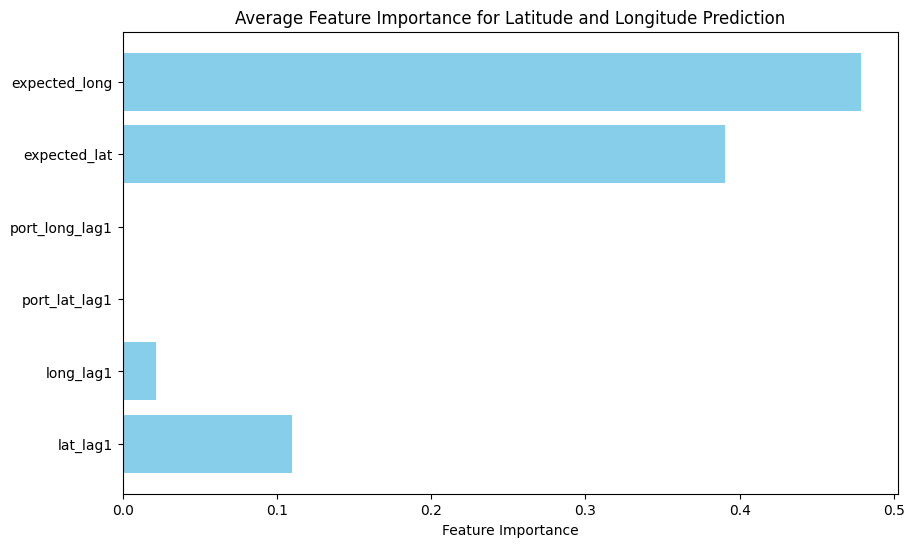

Latitude: MAE: 0.03, R^2: 1.00
Longitude: MAE: 0.05, R^2: 1.00
Average deviation: 6573.30 meters


In [20]:
# Implementing a RandomForestRegressor
# First defining training, test sets and target predictors.
features = ['lat_lag1', 'long_lag1',
            'port_lat_lag1', 'port_long_lag1',
            'expected_lat', 'expected_long'
            ]


train_df, val_df = train_test_split(df_train, test_size=0.2, random_state=42)
X_train = train_df[features].copy()
X_val = val_df[features].copy()

y_train = train_df[['latitude', 'longitude']].copy()
y_val_lat = val_df['latitude'].copy()
y_val_long = val_df['longitude'].copy()

RFR = RandomForestRegressor(n_estimators = 100, max_depth = 20, n_jobs = -1, random_state = 42)

multi_output_regressor = MultiOutputRegressor(RFR)

multi_output_regressor.fit(X_train, y_train)

y_pred = multi_output_regressor.predict(X_val)

y_pred_lat = y_pred[:, 0]
y_pred_long = y_pred[:, 1]

# Extract feature importances for each target
latitude_importances = multi_output_regressor.estimators_[0].feature_importances_
longitude_importances = multi_output_regressor.estimators_[1].feature_importances_

# Average feature importances across targets for a combined importance
average_importances = np.mean([latitude_importances, longitude_importances], axis=0)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, average_importances, color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Average Feature Importance for Latitude and Longitude Prediction")
plt.show()

mae_lat = mean_absolute_error(y_val_lat, y_pred_lat)
mae_long = mean_absolute_error(y_val_long, y_pred_long)
r2_lat = r2_score(y_val_lat, y_pred_lat)
r2_long = r2_score(y_val_long, y_pred_long)
# Calculate the average distance in meters between predicted and actual positions in the validation set
average_distance = average_distance_in_meters(y_val_lat, y_val_long, y_pred_lat, y_pred_long)

print(f'Latitude: MAE: {mae_lat:.2f}, R^2: {r2_lat:.2f}')
print(f'Longitude: MAE: {mae_long:.2f}, R^2: {r2_long:.2f}')

print(f'Average deviation: {average_distance:.2f} meters')

**Random Forest Regressor model for Kaggle**

In [ ]:
df_train[['vesselId', 'time', 'latitude', 'last_lat']]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   41.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   43.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.8min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


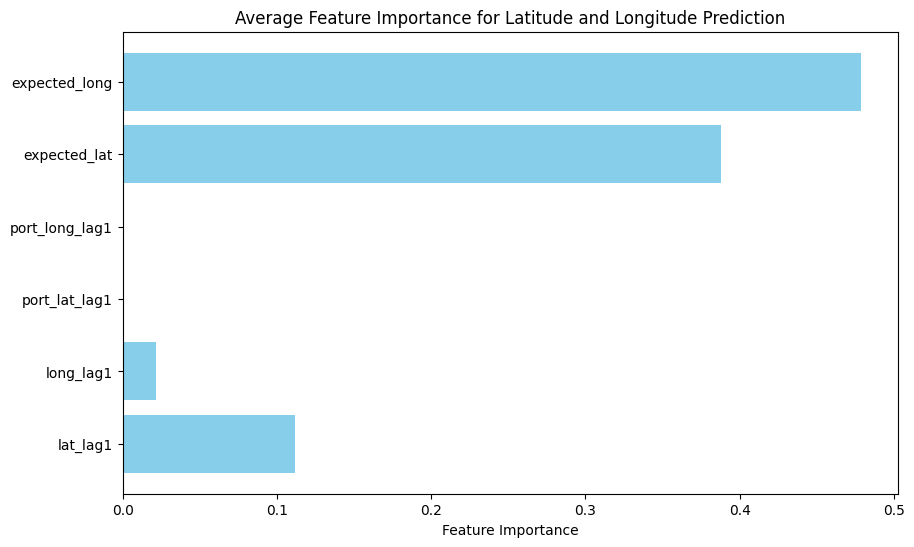

Results saved to jakobs_results_2.csv


In [21]:
# Implementing a RandomForestRegressor
# First defining training, test sets and target predictors.
features = ['lat_lag1', 'long_lag1',
            'port_lat_lag1', 'port_long_lag1',
            'expected_lat', 'expected_long'
            ]

X_train = df_train[features].copy()
X_test = df_test[features].copy()

y_train = df_train[['latitude', 'longitude']].copy()

RFR = RandomForestRegressor(n_estimators = 100, max_depth = 20, n_jobs = -1, random_state = 42, verbose = 1)
multi_output_regressor = MultiOutputRegressor(RFR)

multi_output_regressor.fit(X_train, y_train)

y_pred = multi_output_regressor.predict(X_test)

y_pred_lat = y_pred[:, 0]
y_pred_long = y_pred[:, 1]

# Extract feature importances for each target
latitude_importances = multi_output_regressor.estimators_[0].feature_importances_
longitude_importances = multi_output_regressor.estimators_[1].feature_importances_

# Average feature importances across targets for a combined importance
average_importances = np.mean([latitude_importances, longitude_importances], axis=0)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, average_importances, color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Average Feature Importance for Latitude and Longitude Prediction")
plt.show()

submit(df_test['ID'], y_pred_long, y_pred_lat)

In [25]:
print(pd.Series(y_pred_long).describe())
print(pd.Series(y_pred_lat).describe())

count    51739.000000
mean         9.411026
std         56.756029
min       -122.961591
25%         -5.514850
50%          4.211421
75%         14.277990
max        175.009327
dtype: float64
count    51739.000000
mean        38.799955
std         22.043854
min        -43.538227
25%         35.987165
50%         43.580762
75%         52.189501
max         63.673490
dtype: float64
